In [1]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#import dataset 
import os
import openpyxl
pwd = os.getcwd()
dataset = pd.read_excel(pwd + "/data/DATA.xlsx")
dataset_copy = dataset.copy()
dataset_copy.head(4)

,Datetime,Date,Year,Month,Day,Time,Hour,Temperature,Holiday,Daytype,Frequency of use [Cooker],Frequency of use [Light],Frequency of use [Laptop],Frequency of use [Kettle],Frequency of use [Fan],Frequency of use [Ipod/Tab/Phone],Frequency of use in a day [Iron],Power
0,2022-09-01 00:00:00,2022-09-01,2022,9,1,00:00,0,23.82,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
1,2022-09-01 01:00:00,2022-09-01,2022,9,1,01:00,1,23.68,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
2,2022-09-01 02:00:00,2022-09-01,2022,9,1,02:00,2,23.61,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
3,2022-09-01 03:00:00,2022-09-01,2022,9,1,03:00,3,23.56,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN


In [3]:
#run when modeling
#dataset_copy.drop(['Time','Date'], inplace=True, axis=1)

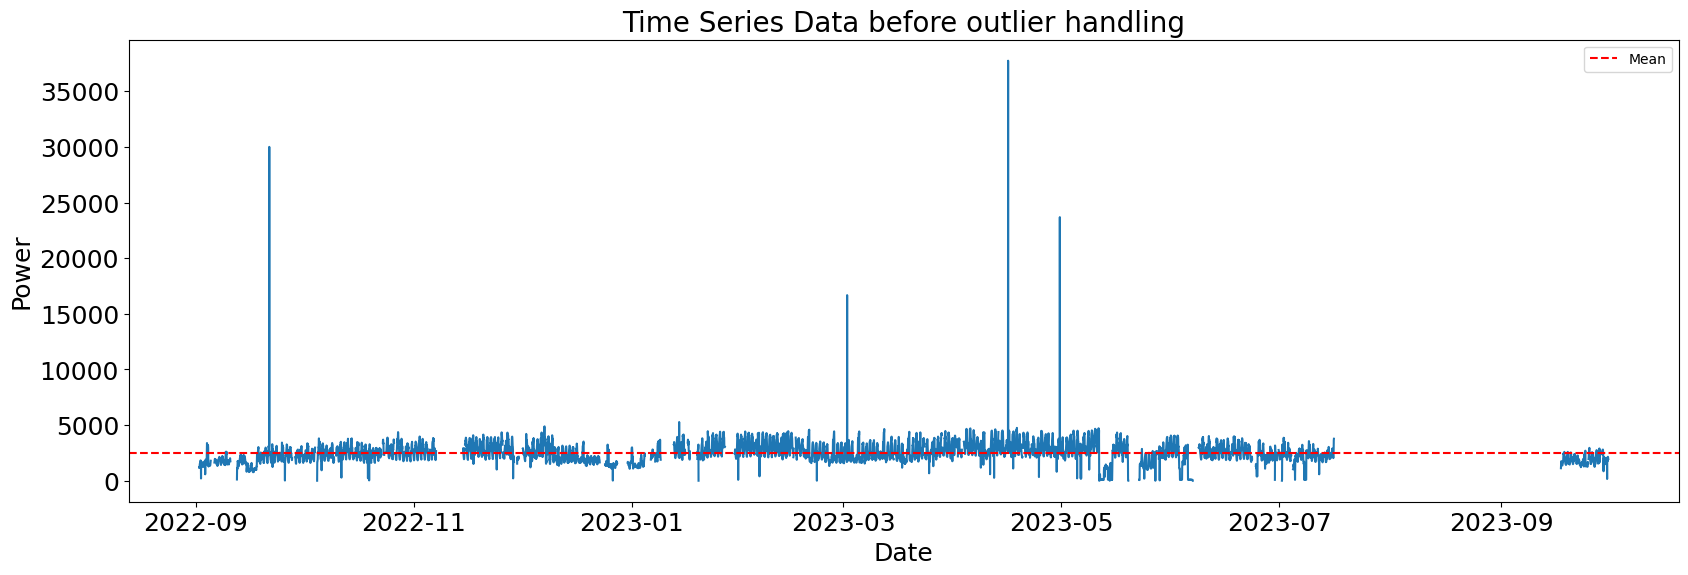

In [4]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
dataset_copy.set_index('Datetime', inplace=True)
plt.plot(dataset_copy['Power'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Power',fontsize=18)
plt.title('Time Series Data before outlier handling',fontsize=20)
plt.axhline(y=dataset['Power'].mean(), color='r', linestyle='--', label='Mean')
plt.legend()
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.show()

In [5]:
# Descriptive Statistics - Calculate statistics for complete and incomplete data
dataset_copy.describe()

,Date,Year,Month,Day,Hour,Temperature,Holiday,Power
count,9480,9480.000000,9480.000000,9480.000000,9480.000000,9480.000000,9480.000000,6922.000000
mean,2023-03-17 00:00:00,2022.691139,6.713924,15.703797,11.500000,26.583504,0.359494,2519.846280
min,2022-09-01 00:00:00,2022.000000,1.000000,1.000000,0.000000,19.480000,0.000000,0.000000
25%,2022-12-08 00:00:00,2022.000000,4.000000,8.000000,5.750000,25.350000,0.000000,1970.250000
50%,2023-03-17 00:00:00,2023.000000,7.000000,16.000000,11.500000,26.460000,0.000000,2434.000000
75%,2023-06-24 00:00:00,2023.000000,9.000000,23.000000,17.250000,27.700000,1.000000,3048.000000
max,2023-09-30 00:00:00,2023.000000,12.000000,31.000000,23.000000,31.580000,1.000000,37752.000000
std,NaN,0.462048,3.378693,8.786290,6.922552,1.667294,0.479877,1044.750604


In [6]:
# change data type to string
# dataset_copy = dataset_copy.astype(str)
dataset_copy.dtypes

Date                                 datetime64[ns]
Year                                          int64
Month                                         int64
Day                                           int64
Time                                         object
Hour                                          int64
Temperature                                 float64
Holiday                                       int64
Daytype                                      object
Frequency of use [Cooker]                    object
Frequency of use [Light]                     object
Frequency of use [Laptop]                    object
Frequency of use [Kettle]                    object
Frequency of use [Fan]                       object
Frequency of use [Ipod/Tab/Phone]            object
Frequency of use in a day [Iron]             object
Power                                       float64
dtype: object

In [7]:
#feature selection import
from pylab import rcParams
import seaborn as sb
from scipy.stats import kendalltau
from scipy.stats import pearsonr

In [8]:
# Data Visualisation Settings 
%matplotlib inline
rcParams['figure.figsize'] = 8,4
sb.set_style('whitegrid')

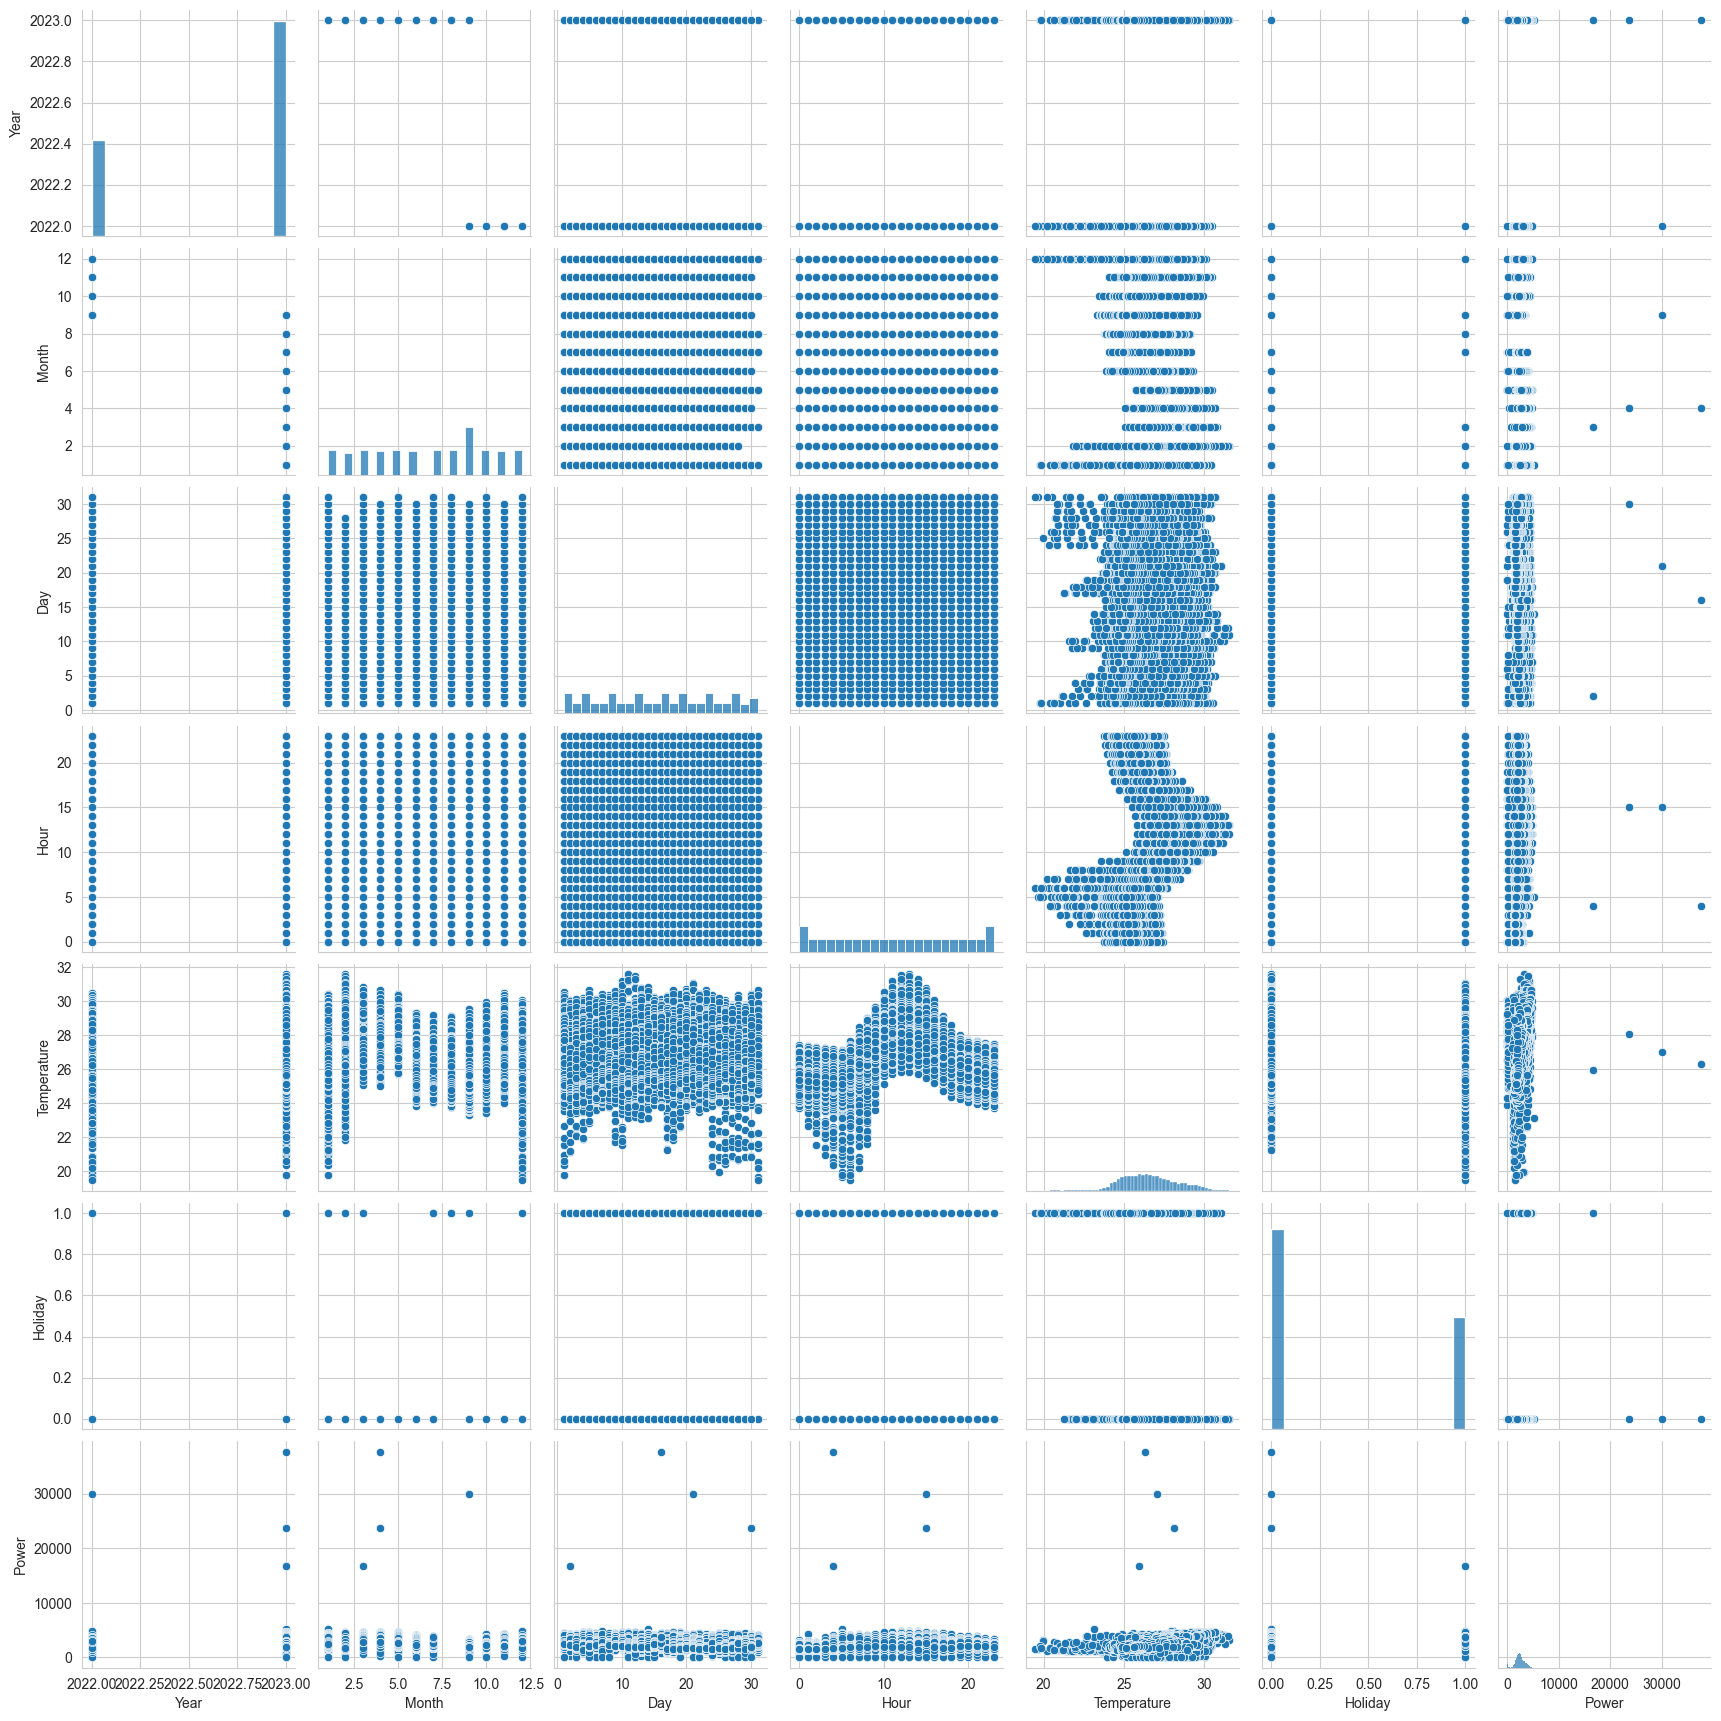

In [9]:
sb.pairplot(dataset_copy)

(array([  3.,   3.,   3.,   5.,  13.,   3.,  11.,  11.,  12.,  11.,  13.,
         16.,  20.,  47., 141., 273., 404., 552., 580., 610., 620., 668.,
        650., 675., 606., 616., 466., 401., 379., 306., 319., 271., 253.,
        212., 147.,  84.,  49.,  15.,   7.,   5.]),
 array([19.48  , 19.7825, 20.085 , 20.3875, 20.69  , 20.9925, 21.295 ,
        21.5975, 21.9   , 22.2025, 22.505 , 22.8075, 23.11  , 23.4125,
        23.715 , 24.0175, 24.32  , 24.6225, 24.925 , 25.2275, 25.53  ,
        25.8325, 26.135 , 26.4375, 26.74  , 27.0425, 27.345 , 27.6475,
        27.95  , 28.2525, 28.555 , 28.8575, 29.16  , 29.4625, 29.765 ,
        30.0675, 30.37  , 30.6725, 30.975 , 31.2775, 31.58  ]),
 <BarContainer object of 40 artists>)

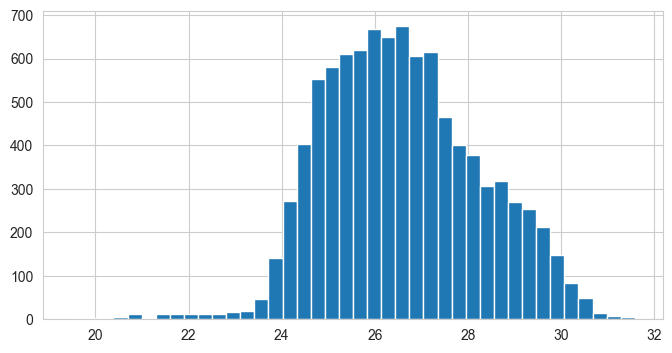

In [10]:
plt.hist(dataset_copy['Temperature'],bins = 40)

In [11]:
#handling outlier using IQR - interquantile range
upper = dataset_copy['Power'].quantile(0.75)
lower = dataset_copy['Power'].quantile(0.25)
IQR = upper - lower
max_threshold = upper + (1.5 * IQR)
min_threshold = lower - (1.5 * IQR)

In [12]:
#dataset_copy[dataset_copy['Power']>max_threshold]

In [13]:
#dataset_copy[dataset_copy['Power']<min_threshold]

In [14]:
#capping outlier
dataset_copy['Power'] = np.where(dataset_copy['Power']>max_threshold, max_threshold, np.where(dataset_copy['Power']<min_threshold, min_threshold,dataset_copy['Power'] ))

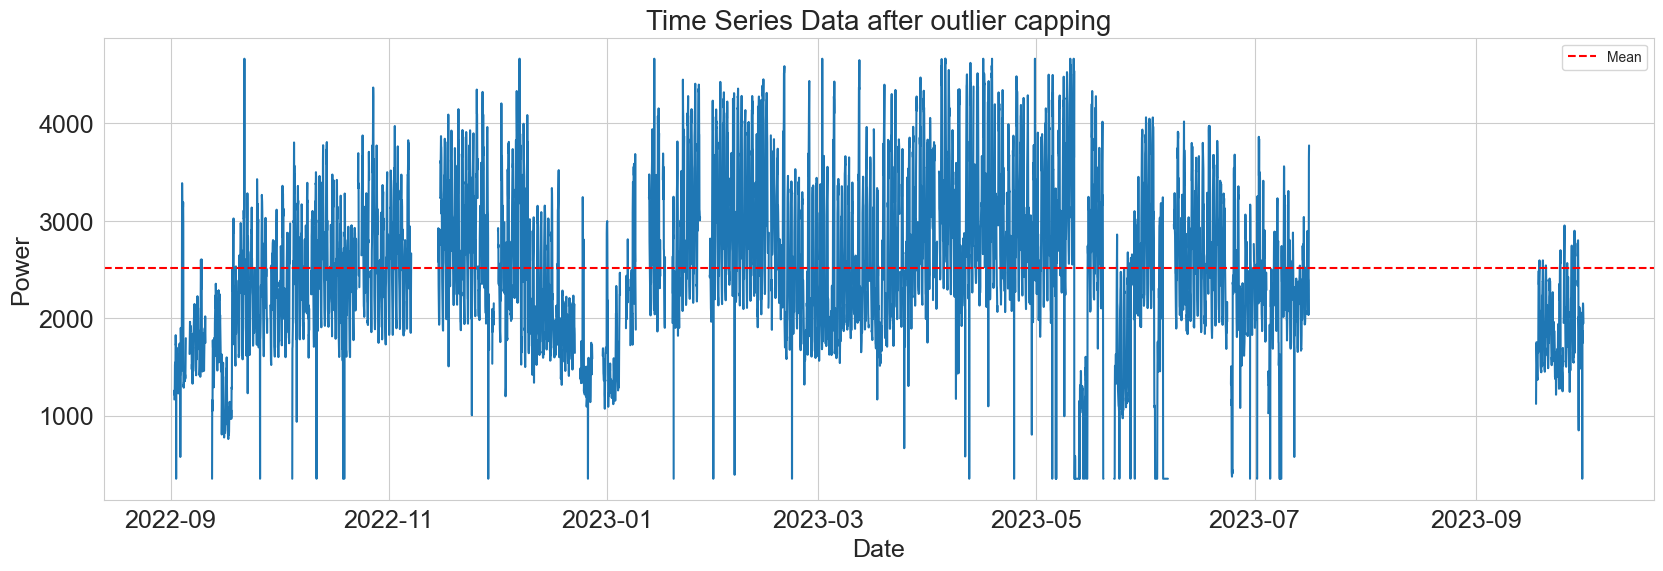

In [15]:
# Visual Inspection - after outlier handling
plt.figure(figsize=(20, 6))
plt.plot(dataset_copy['Power'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Power', fontsize=18)
plt.title('Time Series Data after outlier capping', fontsize=20)
plt.axhline(y=dataset_copy['Power'].mean(), color='r', linestyle='--', label='Mean')
plt.legend()
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.show()

In [16]:
#fill missing value with mean
mean = dataset_copy['Power'].mean()
dataset_copy['Power']= dataset_copy['Power'].fillna(mean)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


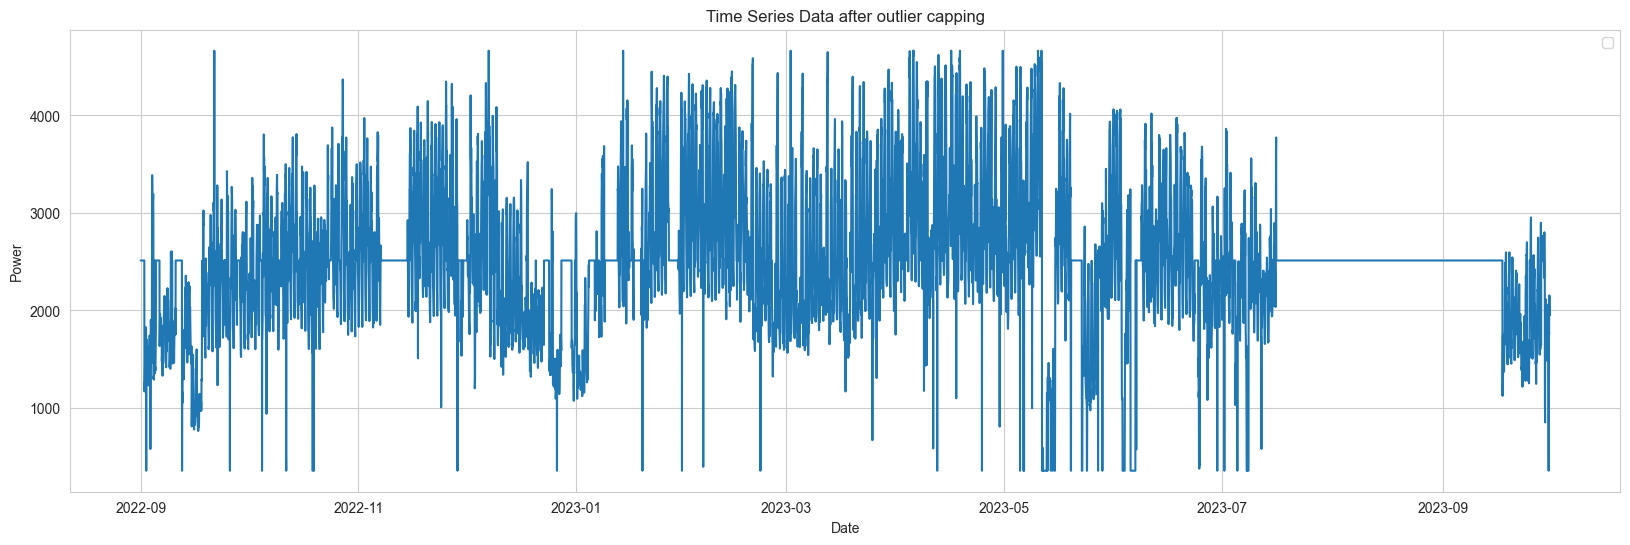

In [17]:
# Visual Inspection - after missing values handling
plt.figure(figsize=(20, 6))
plt.plot(dataset_copy['Power'])
plt.xlabel('Date')
plt.ylabel('Power')
plt.title('Time Series Data after outlier capping')
plt.legend()
plt.show()

In [18]:
dataset_copy.describe()

,Date,Year,Month,Day,Hour,Temperature,Holiday,Power
count,9480,9480.000000,9480.000000,9480.000000,9480.000000,9480.000000,9480.000000,9480.000000
mean,2023-03-17 00:00:00,2022.691139,6.713924,15.703797,11.500000,26.583504,0.359494,2511.614075
min,2022-09-01 00:00:00,2022.000000,1.000000,1.000000,0.000000,19.480000,0.000000,353.625000
25%,2022-12-08 00:00:00,2022.000000,4.000000,8.000000,5.750000,25.350000,0.000000,2146.000000
50%,2023-03-17 00:00:00,2023.000000,7.000000,16.000000,11.500000,26.460000,0.000000,2511.614075
75%,2023-06-24 00:00:00,2023.000000,9.000000,23.000000,17.250000,27.700000,1.000000,2782.000000
max,2023-09-30 00:00:00,2023.000000,12.000000,31.000000,23.000000,31.580000,1.000000,4664.625000
std,NaN,0.462048,3.378693,8.786290,6.922552,1.667294,0.479877,708.941573


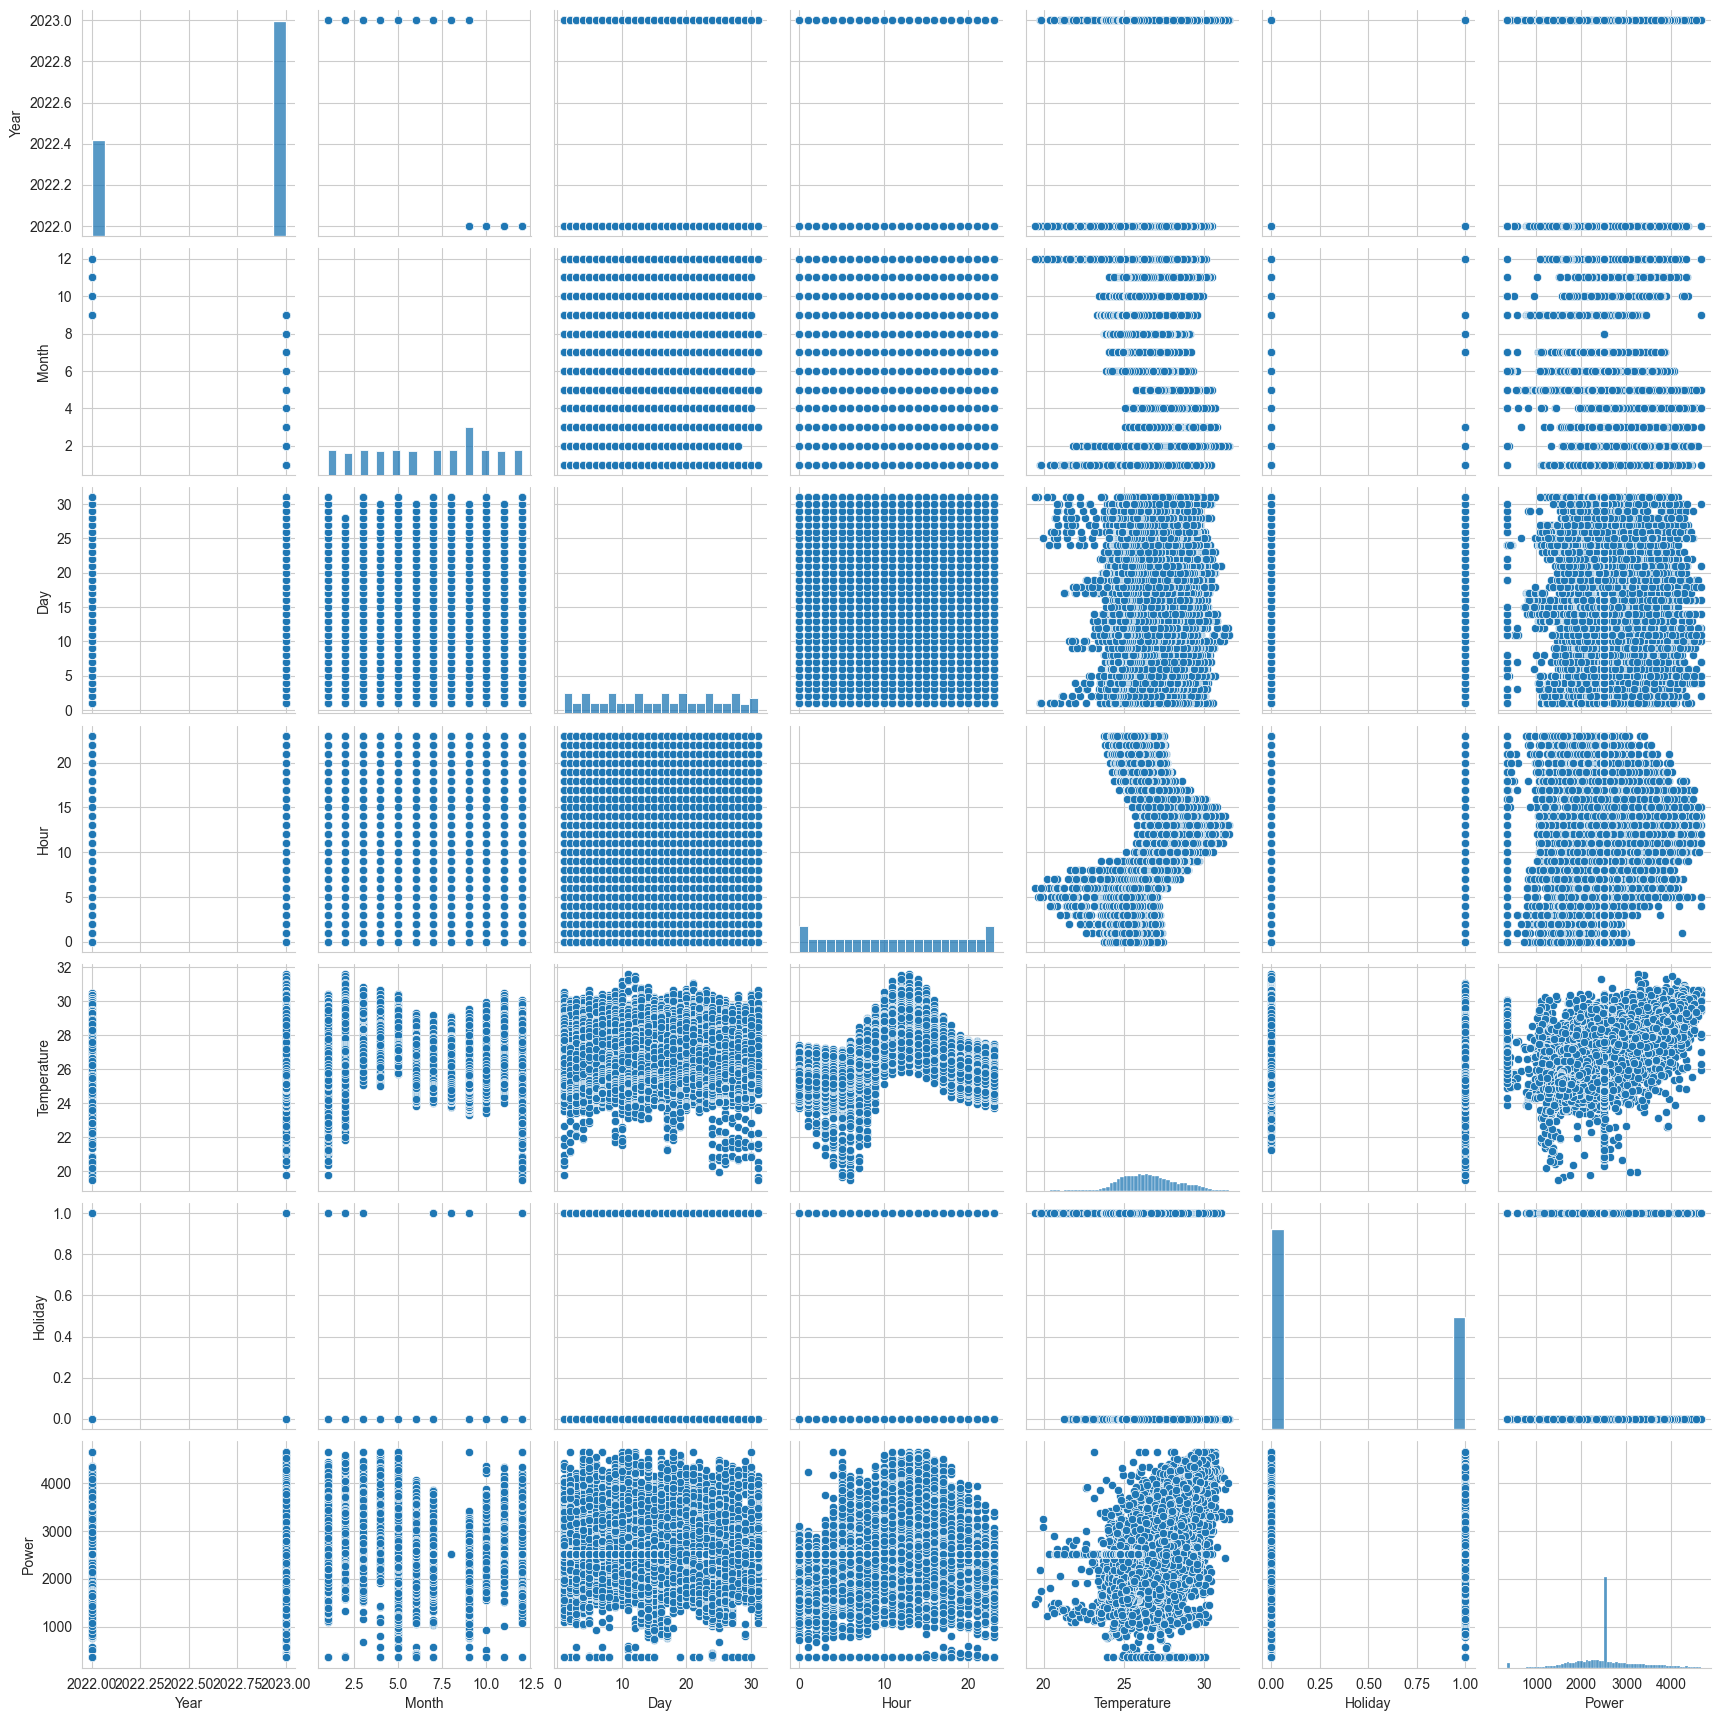

In [19]:
sb.pairplot(dataset_copy)

In [20]:
# converts to numpy array format
X = dataset_copy.iloc[:,:-1].values
Y = dataset_copy.iloc[:,14:].values

In [21]:
# handling missing data - mean imputation
#from sklearn.impute import SimpleImputer
#imputer = SimpleImputer(missing_values= np.nan, strategy= 'mean')
#imputer.fit(Y)
#Y = imputer.transform(Y)

In [22]:
#encoding categorical data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [6,7,8,9,10,11,12,13])], remainder = 'passthrough')
X =  np.array(ct.fit_transform(X))

TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [ ]:
#features selection
corr = dataset_copy.corr(numeric_only=True)

In [ ]:
corr

,Year,Month,Day,Hour,Temperature,Holiday,Power
Year,1.000000e+00,-7.507603e-01,-3.827293e-03,3.744863e-15,0.178633,-2.445708e-02,0.114906
Month,-7.507603e-01,1.000000e+00,9.938684e-03,-5.409849e-16,-0.255121,1.946109e-01,-0.182538
Day,-3.827293e-03,9.938684e-03,1.000000e+00,1.129382e-16,-0.011731,-1.080535e-01,-0.012131
Hour,3.744863e-15,-5.409849e-16,1.129382e-16,1.000000e+00,0.225616,1.869493e-16,0.174296
Temperature,1.786333e-01,-2.551208e-01,-1.173065e-02,2.256162e-01,1.000000,-1.995515e-01,0.433323
Holiday,-2.445708e-02,1.946109e-01,-1.080535e-01,1.869493e-16,-0.199552,1.000000e+00,-0.164027
Power,1.149065e-01,-1.825377e-01,-1.213062e-02,1.742957e-01,0.433323,-1.640271e-01,1.000000


<Axes: >

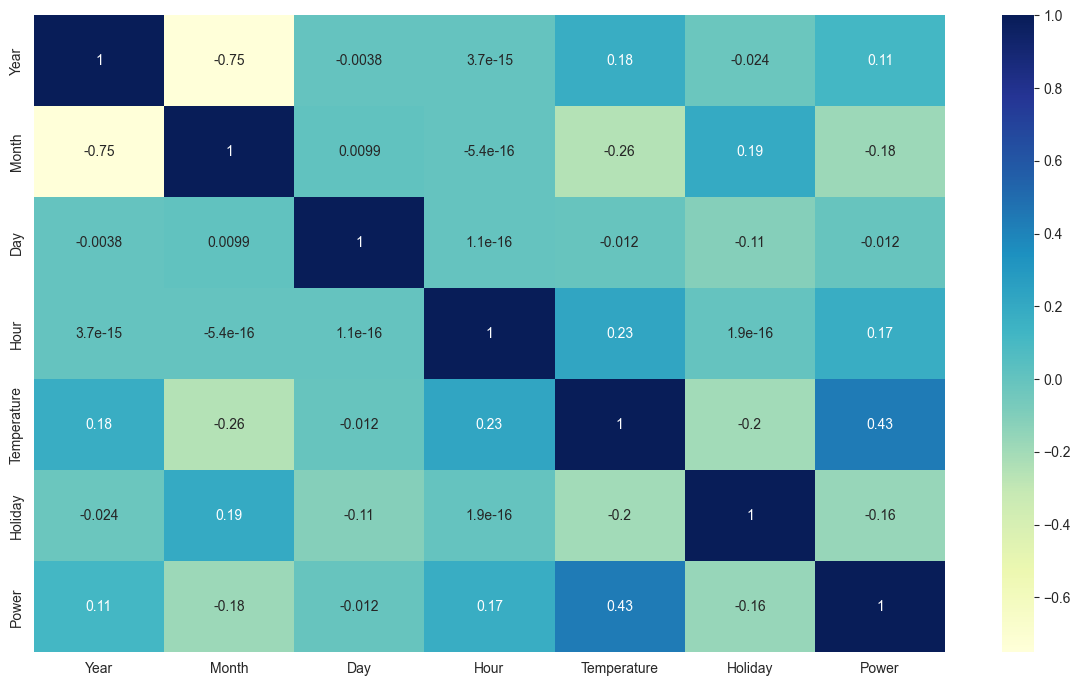

In [ ]:
rcParams['figure.figsize'] = 14.7,8.27
sb.heatmap(corr, 
           xticklabels=corr.columns.values, 
           yticklabels=corr.columns.values, 
           cmap="YlGnBu",
          annot=True)

In [ ]:
#splitting Dataset into training and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=20)

In [ ]:
#Data normalization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:,26] = sc.fit_transform(X_train[:,26].reshape(-1, 1)).flatten()
X_test[:,26] = sc.fit_transform(X_test[:,26].reshape(-1, 1)).flatten()

In [ ]:
y_train = y_train.flatten()
y_test = y_test.flatten()

In [ ]:
#Data exploration - survey 
df = dataset_copy.groupby('Time')['Power'].mean().reset_index(name='AVG')
df['Time'] = df['Time'].astype('str')

In [ ]:
df['AVG'].max()

2917.5410278272543

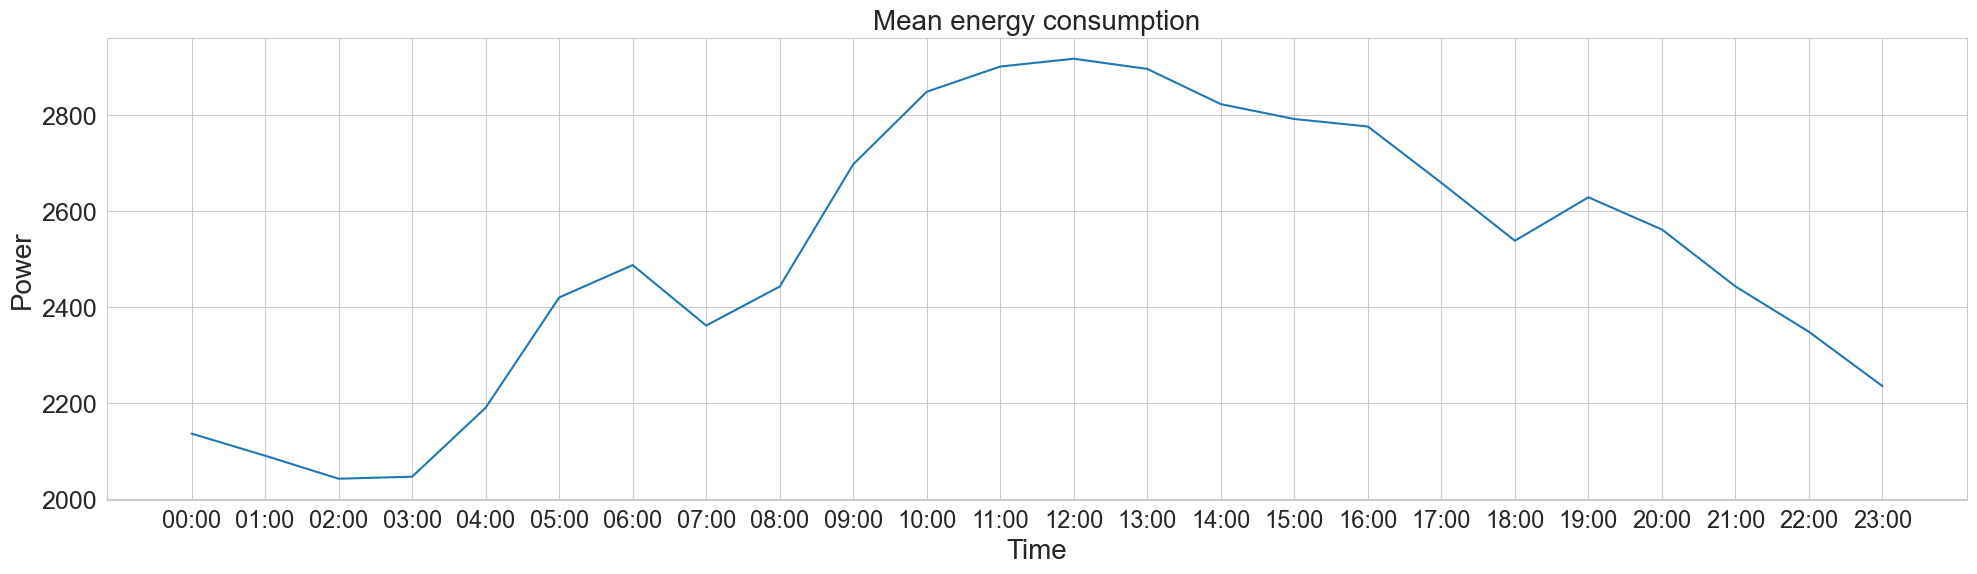

In [ ]:
#Data exploration - survey and 

plt.figure(figsize=(24, 6))
plt.plot(df['Time'], df['AVG'])
plt.xlabel('Time', fontsize=20)
plt.ylabel('Power', fontsize=20)
plt.title('Mean energy consumption', fontsize=20)
#plt.subplots_adjust(bottom=0.8)
plt.tick_params(axis='x', labelsize=17)
plt.tick_params(axis='y', labelsize=18)

plt.show()

In [ ]:
df2= dataset_copy.groupby(['Time', 'Daytype'])['Power'].mean().reset_index(name='AVG')
df2['Time'] = df2['Time'].astype('str')
df_unmelted = df2.pivot(index='Time', columns='Daytype')
#df_unmelted

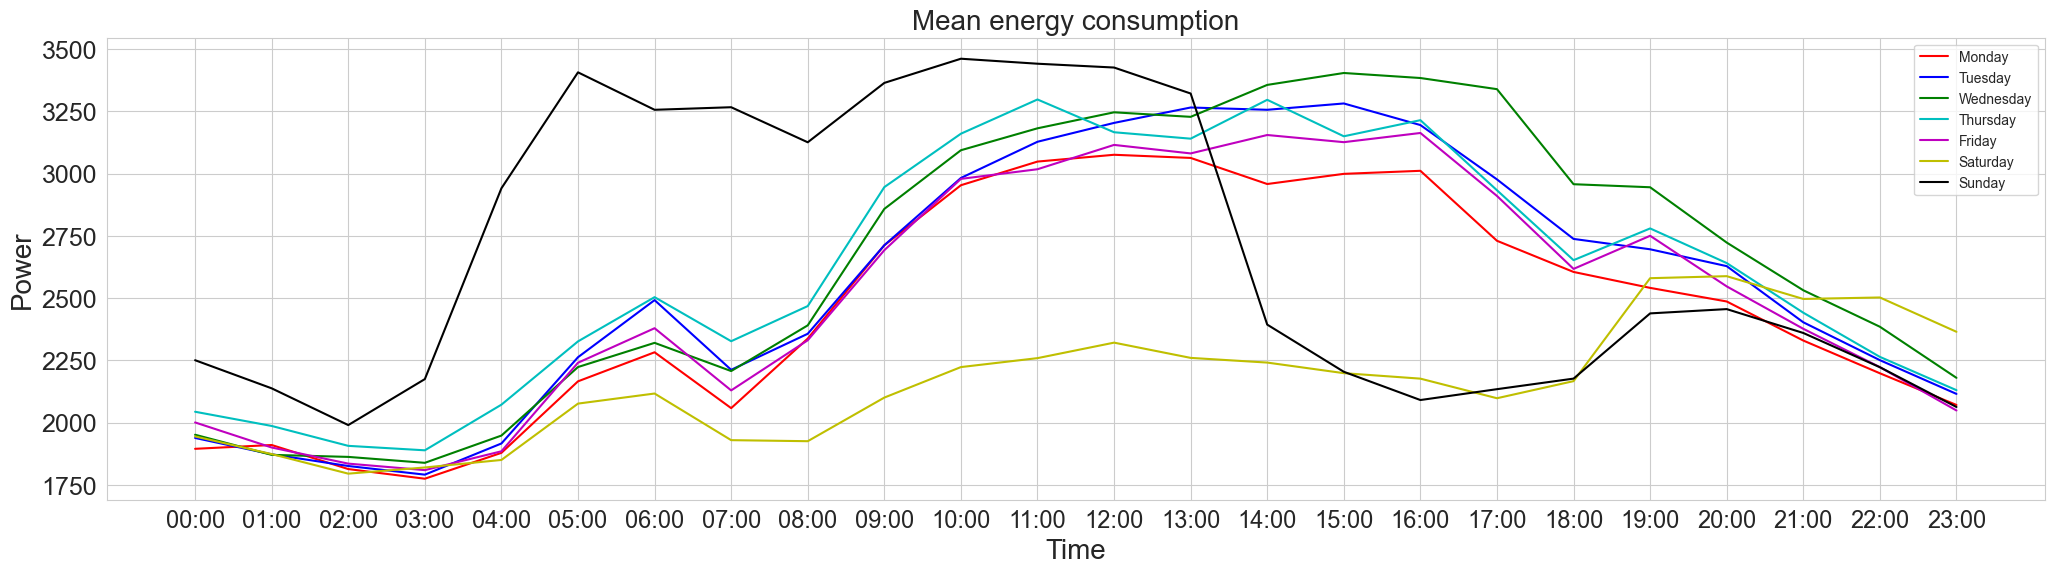

In [ ]:
visualize1 = pd.read_excel(pwd + "/data/byday.xlsx")
visualize1['Time'] = visualize1['Time'].astype('str')
plt.figure(figsize=(25, 6))
plt.plot(visualize1['Time'], visualize1['Monday'],   color='r', label="Monday")
plt.plot(visualize1['Time'], visualize1['Tuesday'],   color='b', label="Tuesday")
plt.plot(visualize1['Time'], visualize1['Wednesday'],   color='g', label="Wednesday")
plt.plot(visualize1['Time'], visualize1['Thursday'],   color='c', label="Thursday")
plt.plot(visualize1['Time'], visualize1['Friday'],   color='m', label="Friday")
plt.plot(visualize1['Time'], visualize1['Saturday'],   color='y', label="Saturday")
plt.plot(visualize1['Time'], visualize1['Sunday'],   color='k', label="Sunday")
plt.xlabel('Time', fontsize=20)
plt.ylabel('Power', fontsize=20)
plt.title('Mean energy consumption', fontsize=20)
plt.legend()
plt.tick_params(axis='x', labelsize=17)
plt.tick_params(axis='y', labelsize=18)
plt.show()

In [ ]:
df3= dataset_copy.groupby(['Time', 'Month'])['Power'].mean().reset_index(name='AVG')
df3['Time'] = df3['Time'].astype('str')
df_unmelted = df3.pivot(index='Time', columns='Month')
#df_unmelted


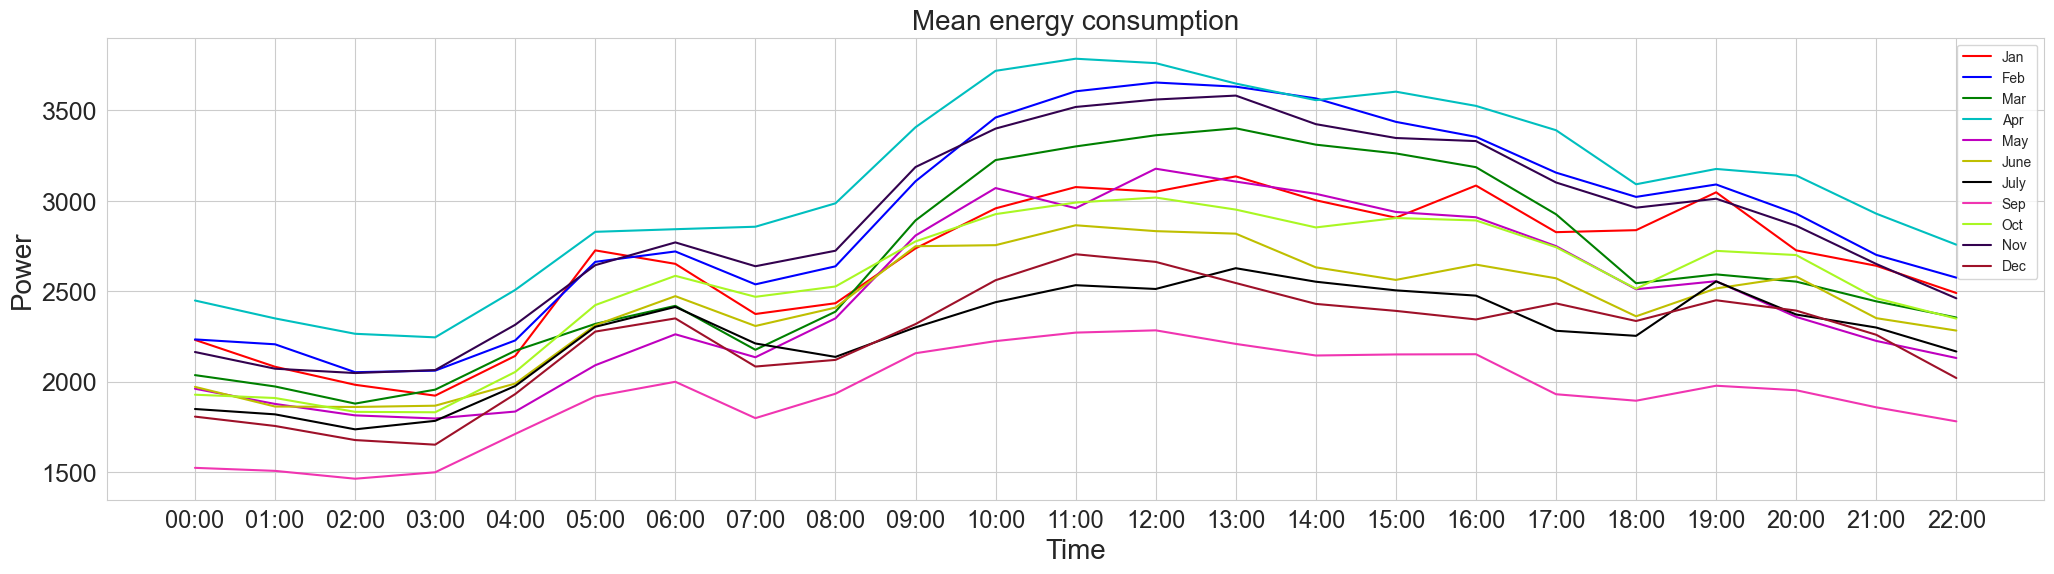

In [ ]:
visualize2 = pd.read_excel(pwd + "/data/bymonth.xlsx")
visualize2['Time'] = visualize2['Time'].astype('str')
plt.figure(figsize=(25, 6))
plt.plot(visualize2['Time'], visualize2['January'],   color='r', label="Jan")
plt.plot(visualize2['Time'], visualize2['February'],   color='b', label="Feb")
plt.plot(visualize2['Time'], visualize2['March'],   color='g', label="Mar")
plt.plot(visualize2['Time'], visualize2['April'],   color='c', label="Apr")
plt.plot(visualize2['Time'], visualize2['May'],   color='m', label="May")
plt.plot(visualize2['Time'], visualize2['June'],   color='y', label="June")
plt.plot(visualize2['Time'], visualize2['July'],   color='k', label="July")
#plt.plot(visualize2['Time'], visualize2['August'],   color='#4bdee3', label="Aug")
plt.plot(visualize2['Time'], visualize2['September'],   color='#f035b1', label="Sep")
plt.plot(visualize2['Time'], visualize2['October'],   color='#a9f723', label="Oct")
plt.plot(visualize2['Time'], visualize2['November'],   color='#33024f', label="Nov")
plt.plot(visualize2['Time'], visualize2['December'],   color='#9e1129', label="Dec")
plt.xlabel('Time', fontsize=20)
plt.ylabel('Power', fontsize=20)
plt.title('Mean energy consumption', fontsize=20)
plt.legend()
plt.tick_params(axis='x', labelsize=17)
plt.tick_params(axis='y', labelsize=18)

plt.show()

In [ ]:
df4= dataset_copy.groupby(['Time', 'Holiday'])['Power'].mean().reset_index(name='AVG')
df4['Time'] = df4['Time'].astype('str')
df_unmelted = df4.pivot(index='Time', columns='Holiday')
#df_unmelted


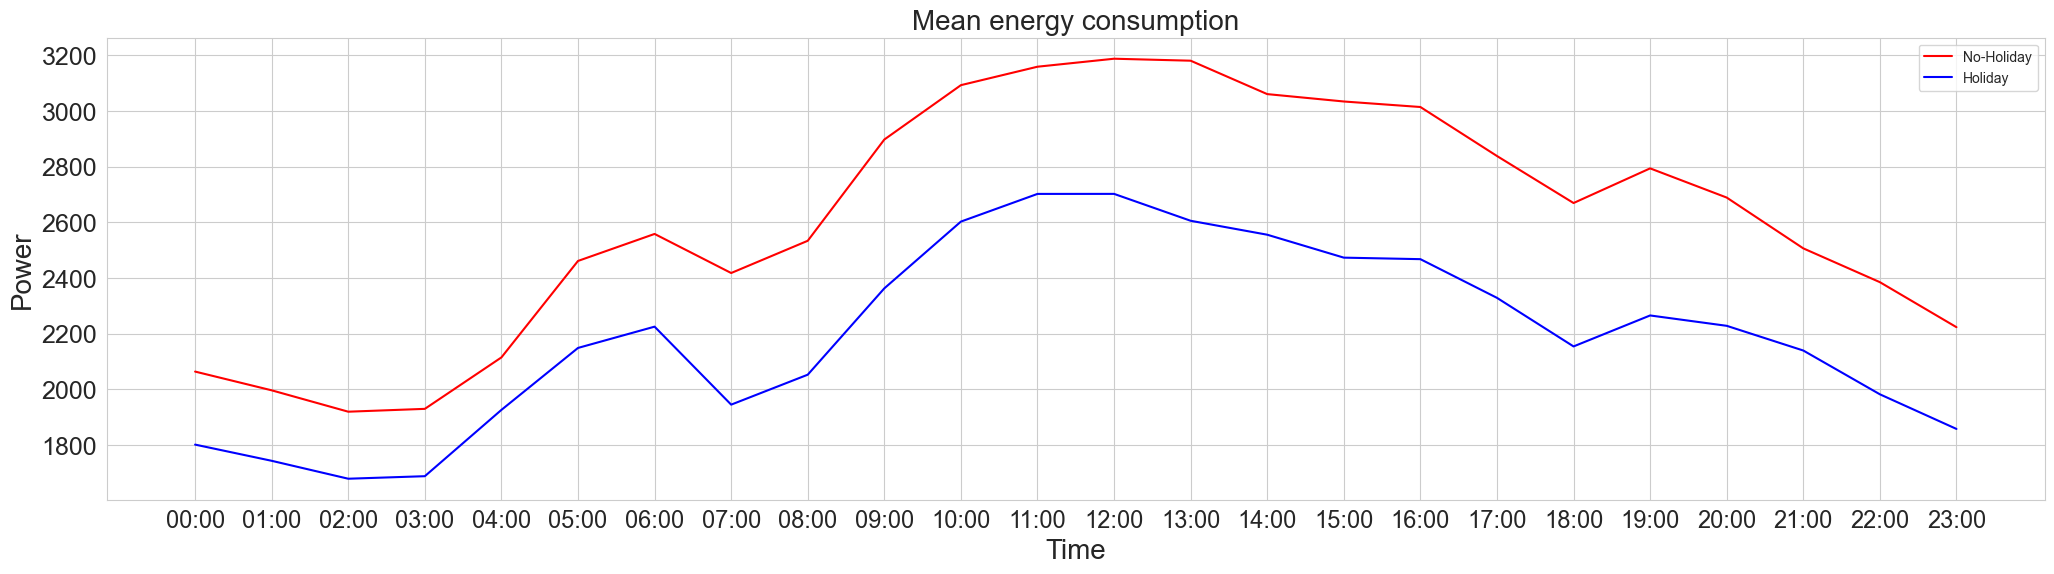

In [ ]:
visualize3 = pd.read_excel(pwd + "/data/Holiday.xlsx")
visualize3['Time'] = visualize3['Time'].astype('str')
plt.figure(figsize=(25, 6))
plt.plot(visualize3['Time'], visualize3['NoHoliday'],   color='r', label="No-Holiday")
plt.plot(visualize3['Time'], visualize3['Holiday'],   color='b', label="Holiday")
plt.xlabel('Time', fontsize=20)
plt.ylabel('Power', fontsize=20)
plt.title('Mean energy consumption', fontsize=20)
plt.legend()
plt.tick_params(axis='x', labelsize=17)
plt.tick_params(axis='y', labelsize=18)
plt.show()

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
 #Initialize SVR model
svr_model = SVR(kernel='rbf')  # Radial Basis Function (RBF) kernel

# Train the SVR model
svr_model.fit(X_train, y_train)

# Predict on the test set
y_pred = svr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape)

# Create a DataFrame to display actual and predicted values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted:")
print(results_df)

Mean Squared Error (MSE): 478137.1498786133
Mean Absolute Error (MAE): 468.0281085388061
Mean Absolute Percentage Error (MAPE): 27.211681225046895
Actual vs Predicted:
           Actual    Predicted
0     1166.000000  2511.542043
1     2644.000000  2511.553016
2     1760.000000  2511.574842
3     2420.000000  2511.539964
4     2511.614075  2511.502518
...           ...          ...
1891  2356.000000  2511.534951
1892  3022.000000  2511.544725
1893  2228.000000  2511.513657
1894  1410.000000  2511.527882
1895  2141.000000  2511.519840

[1896 rows x 2 columns]


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly']
}

# Initialize SVR model
svr_model = SVR()

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(svr_model, param_grid, cv=5, scoring='neg_mean_squared_error')

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Use the best model for prediction
best_svr_model = grid_search.best_estimator_
y_pred_tuned = best_svr_model.predict(X_test)

# Evaluate the tuned model
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mape_tuned = np.mean(np.abs((y_test - y_pred_tuned) / y_test)) * 100

print("Tuned Model Metrics:")
print("Mean Squared Error (MSE):", mse_tuned)
print("Mean Absolute Error (MAE):", mae_tuned)
print("Mean Absolute Percentage Error (MAPE):", mape_tuned)

array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0,
       1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 2023, 6, 25, 18,
       -0.6559927339627324, 0], dtype=object)